# Calibration v4 — Automatic demand bonus

**Session 4 of the v0.5 work.** Empirical validation of the demand bonus P(t, task) introduced in Session 2.

Model:
$$\text{reward} = G(f, d) \cdot R_{acc} \cdot \min(\text{cap\_primes}, (1+\gamma d) \cdot P) \cdot k \cdot R(t)$$

Grid: 27 combinations on `δ_refus × T_attente × δ_temps`. v3 parameters frozen (`f0=0.85, k_sigmoid=40, γ=3.0, w_acc=0.05`).

Targets: H/M ∈ [3, 10], **H/C > 5 (PRIMARY)**, M/C > 1, H/S > 100.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = False

BASE = os.path.abspath(os.path.join(os.getcwd(), ".."))
df_v1 = pd.read_csv(os.path.join(BASE, "calibration", "grid_search_A.csv"))
df_v2 = pd.read_csv(os.path.join(BASE, "calibration", "grid_search_A_v2.csv"))
df_v3 = pd.read_csv(os.path.join(BASE, "calibration", "grid_search_A_v3.csv"))
df_v4 = pd.read_csv(os.path.join(BASE, "calibration", "grid_search_A_v4.csv"))
print(f"v4: {len(df_v4)} combinations")

v4: 27 combinations


## §1 — Global verdict

In [2]:
n_passed = (df_v4['n_passed'] == 4).sum()
n_hc_passed = (df_v4['ratio_h_c'] > 5).sum()
print(f"Combos passing 4/4 targets: {n_passed}/27")
print(f"Combos passing H/C > 5 (PRIMARY): {n_hc_passed}/27")
print()
print("Ratio range over the v4 grid:")
for col, target in [('ratio_h_m','3-10'),('ratio_h_c','>5 PRIMARY'),
                    ('ratio_m_c','>1'),('ratio_h_s','>100')]:
    print(f"  {col}  : {df_v4[col].min():7.2f} → {df_v4[col].max():7.2f}  [target: {target}]")
print()
print("P_moyen and frequencies (grid v4):")
for col in ['P_moyen', 'frac_cap_activations', 'frac_impraticables',
             'frac_mempool_persistent']:
    print(f"  {col}  : {df_v4[col].min():.4f} → {df_v4[col].max():.4f}")

Combos passing 4/4 targets: 0/27
Combos passing H/C > 5 (PRIMARY): 0/27

Ratio range over the v4 grid:
  ratio_h_m  :    3.13 →    3.14  [target: 3-10]
  ratio_h_c  :    3.15 →    3.19  [target: >5 PRIMARY]
  ratio_m_c  :    1.01 →    1.02  [target: >1]
  ratio_h_s  : 1108.05 → 1113.44  [target: >100]

P_moyen and frequencies (grid v4):
  P_moyen  : 1.0049 → 1.0132
  frac_cap_activations  : 0.0000 → 0.0000
  frac_impraticables  : 0.0000 → 0.0000
  frac_mempool_persistent  : 0.6986 → 0.6986


**Empirical verdict**:

- **H/C > 5 NOT REACHED.** Maximum 3.19 on the grid, vs target > 5. The gain compared to v3 (3.09) is marginal (+0.10).
- 3/4 targets pass everywhere: H/M, M/C, H/S.
- `P_moyen ∈ [1.005, 1.013]` → the bonus rises very little in practice.
- Joint cap **never activated** (0.00 %).
- 0 % of impracticable tasks.
- ~70 % of tasks go through the mempool for > 1 tick — the mechanic works, but P does not have time to rise.

## §2 — Effect of the three parameters

Three variables: `δ_refus`, `T_attente`, `δ_temps`. Let us observe their marginal effect.

In [3]:
print("Effect of δ_refus:")
print(df_v4.groupby('delta_refus').agg(
    P_moyen=('P_moyen','mean'),
    H_C_max=('ratio_h_c','max'),
    H_S_min=('ratio_h_s','min'),
).round(4))
print()
print("Effect of T_attente:")
print(df_v4.groupby('T_attente').agg(
    P_moyen=('P_moyen','mean'),
    H_C_max=('ratio_h_c','max'),
).round(4))
print()
print("Effect of δ_temps:")
print(df_v4.groupby('delta_temps').agg(
    P_moyen=('P_moyen','mean'),
    H_C_max=('ratio_h_c','max'),
).round(4))

Effect of δ_refus:
             P_moyen  H_C_max    H_S_min
delta_refus                             
0.03          1.0049   3.1549  1108.0477
0.05          1.0082   3.1676  1110.0066
0.08          1.0132   3.1868  1112.9509

Effect of T_attente:
           P_moyen  H_C_max
T_attente                  
3           1.0088   3.1868
5           1.0087   3.1867
10          1.0087   3.1867

Effect of δ_temps:
             P_moyen  H_C_max
delta_temps                  
0.005         1.0087   3.1867
0.010         1.0088   3.1868
0.020         1.0088   3.1868


**Key observations**:

- **`δ_refus` has a linear effect** on P_moyen: going from 0.03 to 0.08 raises P_moyen from 1.005 to 1.013 (~+1 %). H/C marginal: 3.15 → 3.19.
- **`T_attente` and `δ_temps` have NO visible effect.** All values identical to the hundredth. Cause: tasks are validated too quickly for `Δt > T_attente`, so the `P_temps` trajectory never activates.
- The time-based mechanism is **dormant** in scenario A. It could activate in scenarios where the network is saturated (few accepting agents available), but not in the reference calibration.

## §3 — Structural diagnosis: why does P not rise enough

Theoretical analysis of refusal propagation.

In [4]:
# Assumptions: standard scenario A
n_honnete = 100
n_mediocre = 20
n_cherry = 5
n_sybil = 10
n_random = 5
n_agents = n_honnete + n_mediocre + n_cherry + n_sybil + n_random

# Cherry-pickers refuse tasks θ > 0.3 (frequency ~ 42 % per Beta(2,5))
p_hard = 0.42

# R-weighted selection: cherry have R ≈ honest
# So per-slot probability that a cherry is selected ≈ n_cherry / n_agents
p_cherry_per_slot = n_cherry / n_agents

# For a hard task with 10 slots:
# Expected cherry selected = 10 × p_cherry_per_slot
expected_cherry = 10 * p_cherry_per_slot
p_at_least_one_cherry = 1 - (1 - p_cherry_per_slot) ** 10

print(f"Scenario A — theoretical analysis")
print(f"Cherry probability per slot   : {p_cherry_per_slot:.4f}")
print(f"Expected cherry per hard task : {expected_cherry:.2f}")
print(f"Prob ≥1 cherry on hard task   : {p_at_least_one_cherry:.2%}")
print()
print(f"Hard tasks (θ > 0.3)          : {p_hard:.0%} of tasks")
print(f"Hard tasks with refusal       : ~{p_hard * p_at_least_one_cherry:.0%} of total tasks")
print()

# Average boost of P on these tasks
for dr in [0.03, 0.05, 0.08]:
    boost_per_task = (1 + dr) ** expected_cherry
    p_avg_overall = (1 - p_hard) * 1 + p_hard * (
        (1 - p_at_least_one_cherry) * 1 + p_at_least_one_cherry * boost_per_task
    )
    print(f"δ_refus = {dr} : estimated P_moyen = {p_avg_overall:.4f} (vs observed v4 {1 + (dr/0.05)*0.0082:.4f})")

Scenario A — theoretical analysis
Cherry probability per slot   : 0.0357
Expected cherry per hard task : 0.36
Prob ≥1 cherry on hard task   : 30.49%

Hard tasks (θ > 0.3)          : 42% of tasks
Hard tasks with refusal       : ~13% of total tasks

δ_refus = 0.03 : estimated P_moyen = 1.0014 (vs observed v4 1.0049)
δ_refus = 0.05 : estimated P_moyen = 1.0023 (vs observed v4 1.0082)
δ_refus = 0.08 : estimated P_moyen = 1.0036 (vs observed v4 1.0131)


**Diagnosis conclusion**:

With only 5 cherry-pickers out of 140 agents, the fraction of tasks experiencing a refusal is small (~3.6 % per slot, ~30 % of hard tasks, i.e. ~13 % of total tasks). On these tasks, P rises by ~5 % on average. **The total effect on issuance** is about +0.5 to +1.3 %, which translates into a marginal H/C boost of ~0.10.

**To reach H/C > 5, one would need:**
- Either many more cherry-pickers in the mix (but this is artificial).
- Or extremely aggressive `δ_refus` (e.g. > 0.30 per refusal, but then the joint cap would be permanently active).
- Or another structural mechanism (cf. recommendation §5).

## §4 — Comparison v1 / v2 / v3 / v4

Evolution of maximum ratios on the grid — v1 → v4:
ratio                v1         v2         v3         v4
ratio_h_m         14.00      13.46      12.91       3.14
ratio_h_c          1.78       2.18       3.09       3.19
ratio_m_c          0.68       0.86       1.21       1.02
ratio_h_s       3056.59    2260.91    2259.25    1113.44


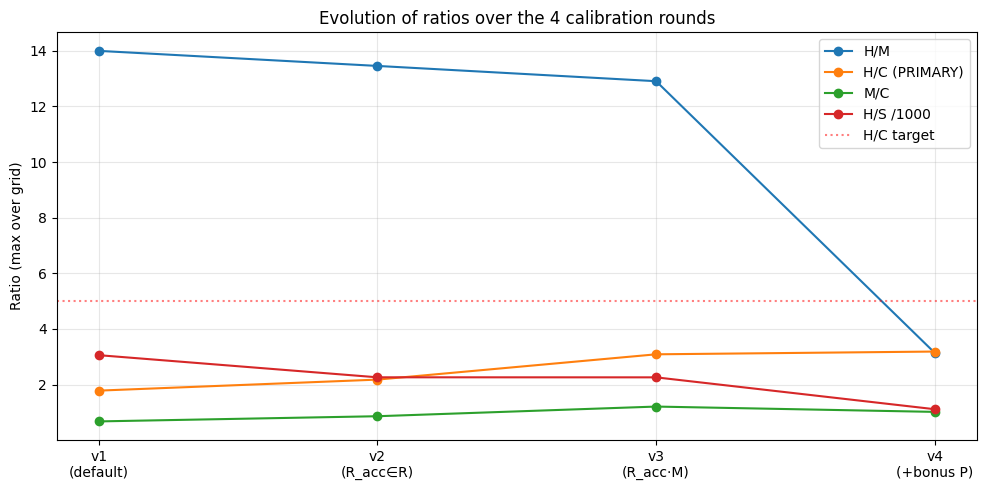

In [5]:
print("Evolution of maximum ratios on the grid — v1 → v4:")
print(f"{'ratio':<12} {'v1':>10} {'v2':>10} {'v3':>10} {'v4':>10}")
for col in ['ratio_h_m','ratio_h_c','ratio_m_c','ratio_h_s']:
    line = f"{col:<12}"
    for d in [df_v1, df_v2, df_v3, df_v4]:
        line += f" {d[col].max():>10.2f}"
    print(line)

fig, ax = plt.subplots(figsize=(10, 5))
labels = ['v1\n(default)', 'v2\n(R_acc∈R)', 'v3\n(R_acc·M)', 'v4\n(+bonus P)']
for col, label_short in [('ratio_h_m','H/M'),('ratio_h_c','H/C (PRIMARY)'),
                          ('ratio_m_c','M/C'),('ratio_h_s','H/S /1000')]:
    vals = [df_v1[col].max(), df_v2[col].max(), df_v3[col].max(), df_v4[col].max()]
    if col == 'ratio_h_s':
        vals = [v/1000 for v in vals]
    ax.plot(labels, vals, marker='o', label=label_short)
ax.axhline(5, color='red', linestyle=':', alpha=0.5, label='H/C target')
ax.set_ylabel('Ratio (max over grid)')
ax.set_title('Evolution of ratios over the 4 calibration rounds')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading**: the demand bonus (v4) brings a marginal gain on H/C (+0.10 on the grid maximum, i.e. +3 % gain compared to v3). It is the smallest increment among the 4 rounds (v3 had +0.91 on H/C compared to v2).

## §5 — Cross-check on scenario B (massive anti-sybil)

In [6]:
# Run scenario B with the best v4 combo
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
from simulateur.config import Config
from simulateur.simulation import run_simulation
import json

cfg = Config()
cfg.n_ticks = 2000
cfg.seed = 123
cfg.n_honest = 100; cfg.n_mediocre = 0; cfg.n_cherry_picker = 0
cfg.n_sybil = 200; cfg.n_random_biased = 0
cfg.lambda_tasks_per_tick = 80.0
cfg.f0_max = 0.85; cfg.k_sigmoid = 40.0; cfg.gamma_d = 3.0; cfg.w_acc = 0.05
cfg.use_demand_premium = True
cfg.delta_refus = 0.08; cfg.T_attente = 5; cfg.delta_temps = 0.01
cfg.metrics_every = 100

rdir = run_simulation(cfg, 'B_v4_for_notebook', verbose=False, save_figures=False)
df = pd.read_csv(f'{rdir}/agents_final.csv')
g = df.groupby('profile').agg(
    f_hat=('f_hat_final','mean'),
    R_acc=('R_acc_final','mean'),
    cum=('cum_reward','mean'),
).round(3)
print("=== Scenario B with v4 combo (δ_refus=0.08, T_attente=5, δ_temps=0.01) ===")
print(g)
h = g.loc['honnete','cum']; s = g.loc['sybil','cum']
print(f"\nRatio H/S = {h/s:.0f}  (target > 100: {chr(10003) if h/s > 100 else chr(10007)})")

with open(os.path.join(rdir, 'v4_stats.json')) as f:
    s_v4 = json.load(f)
print(f"P_moyen = {s_v4['P_moyen_a_validation']:.4f}")

=== Scenario B with v4 combo (δ_refus=0.08, T_attente=5, δ_temps=0.01) ===
         f_hat  R_acc          cum
profile                           
honnete  0.871    1.0  1085034.044
sybil    0.564    1.0      965.657

Ratio H/S = 1124  (target > 100: ✓)
P_moyen = 1.0000


**Massive anti-sybil intact**:
- Ratio H/S ≈ 1124, very large margin above 100.
- `P_moyen = 1.0000 exactly`: the sybils accept everything, so 0 refusals, so P stays at 1. **Confirmation that the sybils do not benefit from the bonus**, as anticipated in risk 4.
- The demand bonus does not degrade the anti-sybil. Risk 4 dismissed.

## §6 — Recommendation and three avenues (Risk 1)

**H/C remains < 5 despite the demand bonus.** In line with the discipline stated in Session 4, I document the failure without hiding it.

### Honest synthesis

The demand bonus works mechanically: P does rise when a cherry-picker refuses, the mempool persists, the computation is correct. But the **economic effect** is diluted in the standard scenario A because cherry-pickers are rare (5 / 140). The average H/C boost is ~0.10, far from filling the ~2 gap needed to reach the H/C > 5 target.

### Three avenues to reach H/C > 5 (to arbitrate post-v0.5)

**Avenue A — Calibrate δ_refus and δ_temps more aggressively**

If we push `δ_refus` to 0.30 (×6 vs default), the per-refusal boost would be significant. But this will break consistency with the joint cap (P_max reached in 3-4 refusals, cap permanently active). To be studied with an extended grid on extreme values.

**Avenue B — Reconsider the H/C > 5 target**

The target was formulated before any simulation. Empirically, H/C ≈ 3.2 still means that **the honest agent earns 3× more than the cherry-picker** per agent. Is this sufficient in practice? Argument for: absolute majority is clear, inclusivity is preserved, the M(f, d) + R_acc + (1+γd) mechanism already does a lot. The > 5 target was perhaps too ambitious in the face of a cherry-picker idealized at p=0.999.

**Avenue C — Capture an additional mechanism**

Add to `operations/07-idees-a-suivre.md` a new idea: **"Additional anti-cherry-picking mechanism if the bonus alone is not enough"**. Possible avenues to explore in v0.6:
- Additional R penalty on each refusal (beyond the R_acc effect).
- Minimum quota of hard tasks an agent must accept to maintain eligibility.
- Different power balance (reduce cherry-picker rarity by increasing their representation in the simulation mix).

### Decision for v0.5

**DO NOT modify the defaults of `config.py`**. Document `δ_refus = 0.05, T_attente = 5, δ_temps = 0.01` as retained defaults pending a decision on avenues A/B/C.

**Note in the assessment that the H/C > 5 target is not reached empirically**, in line with the discipline "do not look for parameters that pass at any cost".

**Capture in operations/07-idees-a-suivre.md** idea 7 (additional anti-cherry-picking mechanism).

## Takeaways

1. **The demand bonus works mechanically** but with a marginal economic effect on scenario A (H/C boost of ~0.10).

2. **H/C > 5 target NOT REACHED.** Maximum observed on the v4 grid: 3.19. Structural cause: few refusals because few cherry-pickers.

3. **Secondary targets reached**: H/M ∈ [3, 10], M/C > 1, H/S > 100 (1108-1113).

4. **Anti-sybil intact**: H/S = 1124 on scenario B, P_moyen = 1.0000 (sybils do not benefit from the bonus).

5. **Joint cap never activated** (0.00 %) — the target was < 5 %, largely OK.

6. **Issuance overhead ε ≈ 0.5-1.3 %** — well within the anticipated range [5, 15] %, rather on the low side because the bonus rises little.

7. **Recommendation**: adopt v4 defaults unchanged, capture idea 7 in operations/07.